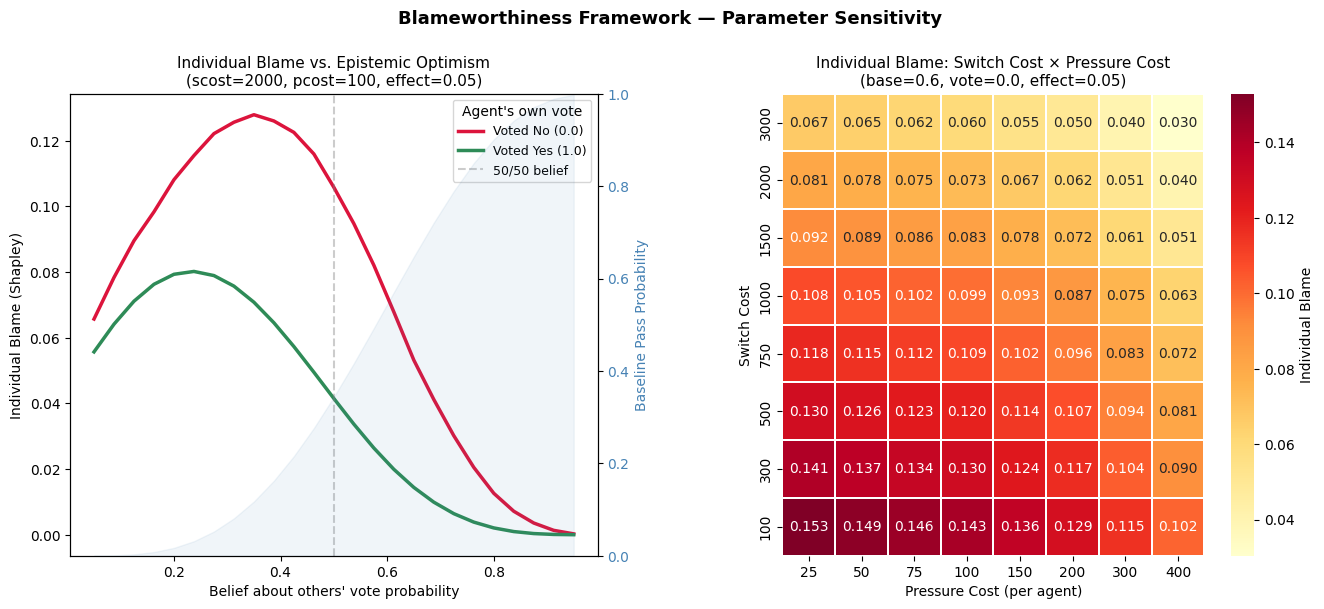

In [1]:
import itertools, math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from committee import BlameCalculator, EpistemicState

# --- paste or import the classes above this point ---
OUT_DIR = 'plots'

AGENTS = ['ag1', 'ag2', 'ag3', 'ag4', 'ag5', 'ag6', 'ag7']
TARGET = 'ag1'
N = 5000

# ── Plot 1 data: sweep base from 0.05 → 0.95 ─────────────────────────────────
base_values = np.linspace(0.05, 0.95, 25)
records1 = []

for base in base_values:
    for vote_label, vote_val in [('Voted No (0.0)', 0.0), ('Voted Yes (1.0)', 1.0)]:
        calc = BlameCalculator(AGENTS, N, pressure_effect=0.05, pressure_cost=100, switch_cost=2000)
        probs = {ag: base for ag in AGENTS}
        probs[TARGET] = vote_val
        e1 = EpistemicState(probs)
        blame = calc.apportion_blame_shapley(TARGET, e1)
        records1.append({
            'Belief about others (base)': base,
            'Own vote': vote_label,
            'Individual Blame': blame,
            'Baseline Pass Prob': e1.get_outcome_probability(),
        })

df1 = pd.DataFrame(records1)

# ── Plot 2 data: sweep scost × pcost ─────────────────────────────────────────
scost_values = [100, 300, 500, 750, 1000, 1500, 2000, 3000]
pcost_values = [25,  50,  75, 100,  150,  200,  300,  400]
records2 = []

for scost in scost_values:
    for pcost in pcost_values:
        calc = BlameCalculator(AGENTS, N, pressure_effect=0.05, pressure_cost=pcost, switch_cost=scost)
        probs = {ag: 0.6 for ag in AGENTS}
        probs[TARGET] = 0.0          # agent voted no — worst case for blame
        e1 = EpistemicState(probs)
        blame = calc.apportion_blame_shapley(TARGET, e1)
        records2.append({'Switch Cost': scost, 'Pressure Cost': pcost, 'Individual Blame': blame})

df2 = pd.DataFrame(records2)
pivot = df2.pivot(index='Switch Cost', columns='Pressure Cost', values='Individual Blame')

# ── Draw ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 6))
gs = GridSpec(1, 2, figure=fig, wspace=0.35)

# --- Plot 1: line plot with dual-layer (blame + pass prob as background) -----
ax1 = fig.add_subplot(gs[0])
ax1b = ax1.twinx()

# Pass probability as a faint reference band (same for both vote conditions since
# it's computed from *others'* beliefs — plot just the no-vote variant)
ref = df1[df1['Own vote'] == 'Voted No (0.0)']
ax1b.fill_between(ref['Belief about others (base)'],
                  ref['Baseline Pass Prob'],
                  alpha=0.08, color='steelblue', label='Pass Prob (ref)')
ax1b.set_ylabel('Baseline Pass Probability', color='steelblue', fontsize=10)
ax1b.tick_params(axis='y', labelcolor='steelblue')
ax1b.set_ylim(0, 1)

sns.lineplot(data=df1, x='Belief about others (base)', y='Individual Blame',
             hue='Own vote', palette=['crimson', 'seagreen'],
             linewidth=2.5, ax=ax1)

ax1.set_title('Individual Blame vs. Epistemic Optimism\n(scost=2000, pcost=100, effect=0.05)', fontsize=11)
ax1.set_xlabel('Belief about others\' vote probability')
ax1.set_ylabel('Individual Blame (Shapley)')
ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4, label='50/50 belief')
ax1.legend(title='Agent\'s own vote', fontsize=9)

# --- Plot 2: heatmap -----------------------------------------------------------
ax2 = fig.add_subplot(gs[1])
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Individual Blame'},
            ax=ax2)
ax2.set_title('Individual Blame: Switch Cost × Pressure Cost\n(base=0.6, vote=0.0, effect=0.05)', fontsize=11)
ax2.set_xlabel('Pressure Cost (per agent)')
ax2.set_ylabel('Switch Cost')
ax2.invert_yaxis()

plt.suptitle('Blameworthiness Framework — Parameter Sensitivity', fontsize=13, fontweight='bold', y=1.02)
plt.savefig(f'{OUT_DIR}/blame_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

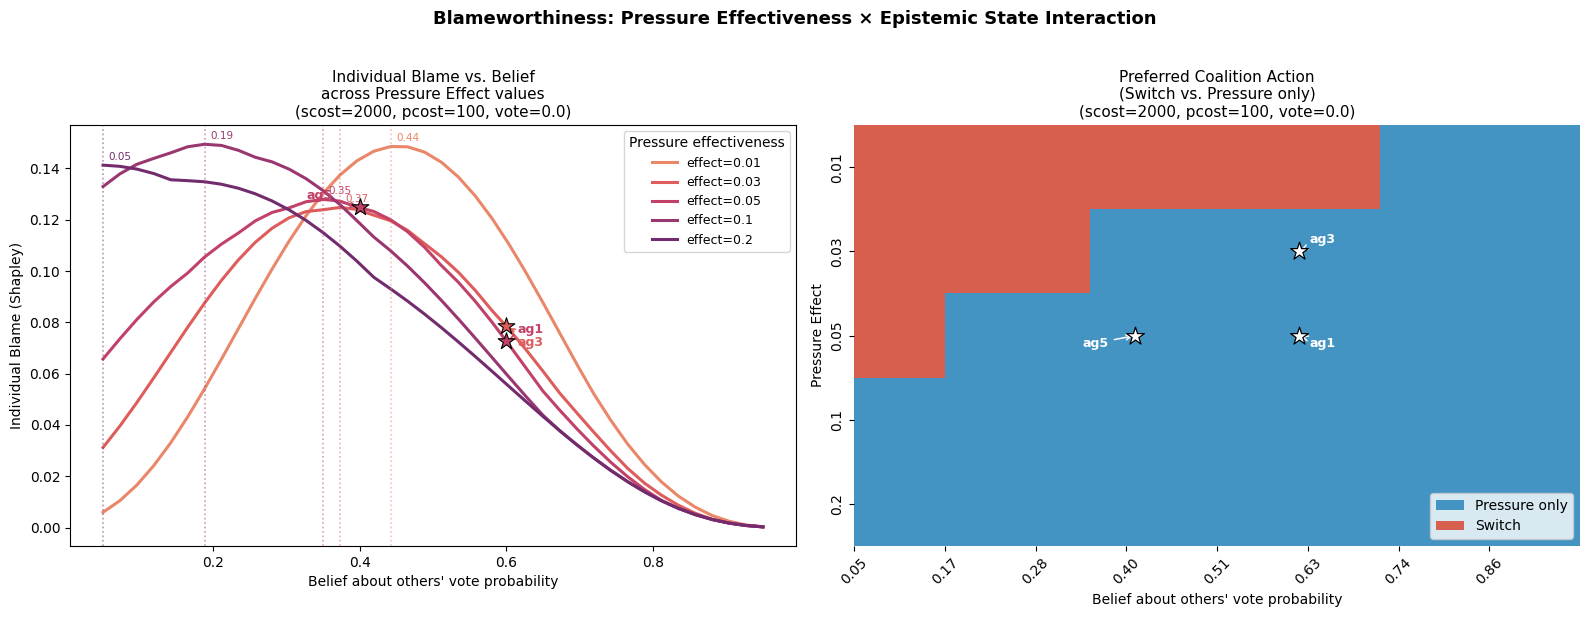

Paper agent blame values (vote=no, pcost=100, scost=2000):
  ag1  base=0.6  effect=0.05  → blame=0.0727
  ag3  base=0.6  effect=0.03  → blame=0.0785
  ag5  base=0.4  effect=0.05  → blame=0.1248


In [2]:

# ── Plot 3: base × effect interaction ─────────────────────────────────────────
# Annotated with paper agents: ag1 (base=0.6, effect=0.05), ag3 (base=0.6, effect=0.03), ag5 (base=0.4, effect=0.05)

effect_values = [0.01, 0.03, 0.05, 0.10, 0.20]
base_values3 = np.linspace(0.05, 0.95, 40)
records3 = []

for effect in effect_values:
    for base in base_values3:
        calc = BlameCalculator(AGENTS, N, pressure_effect=effect, pressure_cost=100, switch_cost=2000)
        probs = {ag: base for ag in AGENTS}
        probs[TARGET] = 0.0
        e1 = EpistemicState(probs)
        blame = calc.apportion_blame_shapley(TARGET, e1)

        e_pressure, cost_p = calc.simulate_action(AGENTS, e1, switcher_id=None, target_id=TARGET)
        e_switch, cost_s   = calc.simulate_action(AGENTS, e1, switcher_id=TARGET, target_id=TARGET)
        gb_pressure = calc.delta(e1, e_pressure) * ((N - cost_p) / N)
        gb_switch   = calc.delta(e1, e_switch)   * ((N - cost_s) / N)
        preferred = 'Switch' if gb_switch > gb_pressure else 'Pressure only'

        records3.append({
            'Belief about others (base)': base,
            'Pressure Effect': effect,
            'effect_label': f'effect={effect}',
            'Individual Blame': blame,
            'Preferred action': preferred,
        })

df3 = pd.DataFrame(records3)

# ── Compute exact blame for paper agents ──────────────────────────────────────
paper_agents = {
    'ag1': {'base': 0.6, 'effect': 0.05},
    'ag3': {'base': 0.6, 'effect': 0.03},
    'ag5': {'base': 0.4, 'effect': 0.05},
}
for name, cfg in paper_agents.items():
    c = BlameCalculator(AGENTS, N, pressure_effect=cfg['effect'], pressure_cost=100, switch_cost=2000)
    p = {ag: cfg['base'] for ag in AGENTS}
    p[TARGET] = 0.0
    e = EpistemicState(p)
    cfg['blame'] = c.apportion_blame_shapley(TARGET, e)

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = sns.color_palette('flare', n_colors=len(effect_values))
effect_color = {e: palette[i] for i, e in enumerate(effect_values)}

ax = axes[0]
sns.lineplot(data=df3, x='Belief about others (base)', y='Individual Blame',
             hue='effect_label', palette=palette, linewidth=2.2, ax=ax)

# Mark peaks
for i, effect in enumerate(effect_values):
    sub = df3[df3['Pressure Effect'] == effect]
    peak_row = sub.loc[sub['Individual Blame'].idxmax()]
    ax.axvline(peak_row['Belief about others (base)'], color=palette[i],
               linestyle=':', alpha=0.5, linewidth=1.2)
    ax.annotate(f"{peak_row['Belief about others (base)']:.2f}",
                xy=(peak_row['Belief about others (base)'], peak_row['Individual Blame']),
                xytext=(4, 4), textcoords='offset points', fontsize=7.5, color=palette[i])

# Annotate paper agents as stars on their respective curves
offsets = {'ag1': (8, 6), 'ag3': (8, -14), 'ag5': (-38, 6)}
for name, cfg in paper_agents.items():
    col = effect_color[cfg['effect']]
    ax.scatter([cfg['base']], [cfg['blame']], s=160, marker='*', zorder=6,
               color=col, edgecolors='black', linewidths=0.8)
    dx, dy = offsets[name]
    ax.annotate(name, xy=(cfg['base'], cfg['blame']), xytext=(dx, dy),
                textcoords='offset points', fontsize=9, fontweight='bold', color=col,
                arrowprops=dict(arrowstyle='->', color=col, lw=1.1))

ax.set_title('Individual Blame vs. Belief\nacross Pressure Effect values\n(scost=2000, pcost=100, vote=0.0)', fontsize=11)
ax.set_xlabel("Belief about others' vote probability")
ax.set_ylabel('Individual Blame (Shapley)')
ax.legend(title='Pressure effectiveness', fontsize=9)

# --- Right: action phase diagram ─────────────────────────────────────────────
ax2 = axes[1]
df3['action_numeric'] = (df3['Preferred action'] == 'Switch').astype(int)
pivot3 = df3.pivot_table(index='Pressure Effect', columns='Belief about others (base)',
                          values='action_numeric', aggfunc='first')

sns.heatmap(pivot3, cmap=sns.color_palette(['#4393c3', '#d6604d'], as_cmap=True),
            linewidths=0, cbar=False, ax=ax2, yticklabels=effect_values)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4393c3', label='Pressure only'),
                   Patch(facecolor='#d6604d', label='Switch')]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=10)

# Annotate paper agents on the phase diagram
base_cols = pivot3.columns.values
eff_rows  = pivot3.index.values
hm_offsets = {'ag1': (8, -8), 'ag3': (8, 6), 'ag5': (-38, -8)}
for name, cfg in paper_agents.items():
    col_idx = np.argmin(np.abs(base_cols - cfg['base']))
    row_idx = np.argmin(np.abs(eff_rows  - cfg['effect']))
    x, y = col_idx + 0.5, row_idx + 0.5
    ax2.scatter([x], [y], s=180, marker='*', zorder=6,
                color='white', edgecolors='black', linewidths=0.9)
    dx, dy = hm_offsets[name]
    ax2.annotate(name, xy=(x, y), xytext=(dx, dy),
                 textcoords='offset points', fontsize=9, fontweight='bold', color='white',
                 arrowprops=dict(arrowstyle='->', color='white', lw=1.1))

ax2.set_title('Preferred Coalition Action\n(Switch vs. Pressure only)\n(scost=2000, pcost=100, vote=0.0)', fontsize=11)
ax2.set_xlabel("Belief about others' vote probability")
ax2.set_ylabel('Pressure Effect')

xtick_positions = range(0, len(pivot3.columns), 5)
ax2.set_xticks(list(xtick_positions))
ax2.set_xticklabels([f"{pivot3.columns[i]:.2f}" for i in xtick_positions], rotation=45)

plt.suptitle('Blameworthiness: Pressure Effectiveness × Epistemic State Interaction',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/blame_effect_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

print("Paper agent blame values (vote=no, pcost=100, scost=2000):")
for name, cfg in paper_agents.items():
    print(f"  {name}  base={cfg['base']}  effect={cfg['effect']}  → blame={cfg['blame']:.4f}")


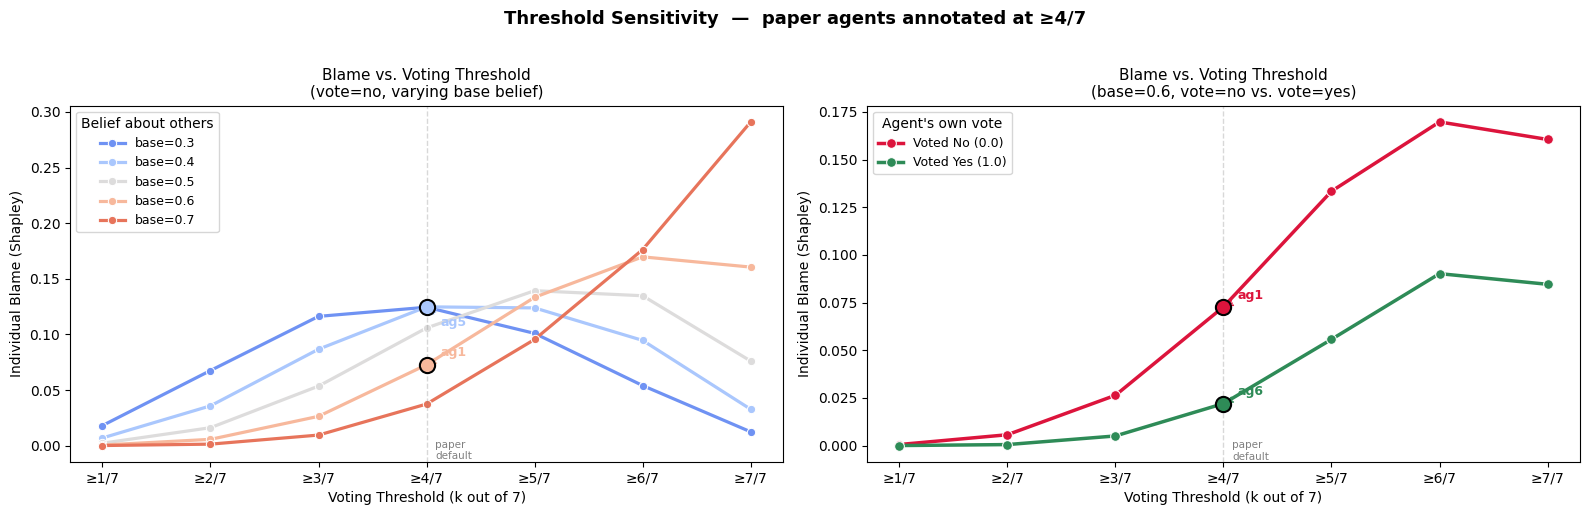

ag1 blame at ≥4/7 (vote=no,  base=0.6): 0.0727
ag5 blame at ≥4/7 (vote=no,  base=0.4): 0.1248
ag1 blame at ≥4/7 (vote=no,  base=0.6): 0.0727
ag6 blame at ≥4/7 (vote=yes, base=0.6): 0.0220


In [3]:

# ── Plot 4: How does blame change as the voting threshold increases? ───────────
# Sweep threshold from 1/7 to 7/7 and observe individual blame.
# Left:  multiple base values, agent voted no
# Right: base=0.6, vote=no vs vote=yes
# Annotated: agents from committee.py sit at threshold=4 (the paper's default)

def blame_for_threshold(threshold, probs, vote_val, agents, N):
    calc = BlameCalculator(agents, N, pressure_effect=0.05, pressure_cost=100, switch_cost=2000)
    probs_copy = probs.copy()
    probs_copy[TARGET] = vote_val
    e1 = EpistemicState(probs_copy, threshold=threshold)
    return calc.apportion_blame_shapley(TARGET, e1)

thresholds  = list(range(1, 8))
base_vals_t = [0.3, 0.4, 0.5, 0.6, 0.7]
records4    = []

for threshold in thresholds:
    for base in base_vals_t:
        probs = {ag: base for ag in AGENTS}
        blame = blame_for_threshold(threshold, probs, vote_val=0.0, agents=AGENTS, N=N)
        records4.append({'Threshold': threshold, 'base_label': f'base={base}',
                         'panel': 'left', 'Individual Blame': blame})

    for vote_label, vote_val in [('Voted No (0.0)', 0.0), ('Voted Yes (1.0)', 1.0)]:
        probs = {ag: 0.6 for ag in AGENTS}
        blame = blame_for_threshold(threshold, probs, vote_val=vote_val, agents=AGENTS, N=N)
        records4.append({'Threshold': threshold, 'base_label': vote_label,
                         'panel': 'right', 'Individual Blame': blame})

df4 = pd.DataFrame(records4)

# ── Look up agent positions at threshold=4 (the paper's default) ──────────────
# Left plot: ag1 (base=0.6, vote=no), ag5 (base=0.4, vote=no)
ag1_left  = df4[(df4['panel'] == 'left') & (df4['base_label'] == 'base=0.6') & (df4['Threshold'] == 4)]['Individual Blame'].values[0]
ag5_left  = df4[(df4['panel'] == 'left') & (df4['base_label'] == 'base=0.4') & (df4['Threshold'] == 4)]['Individual Blame'].values[0]
# Right plot: ag1 (vote=no, base=0.6), ag6 (vote=yes, base=0.6)
ag1_right = df4[(df4['panel'] == 'right') & (df4['base_label'] == 'Voted No (0.0)') & (df4['Threshold'] == 4)]['Individual Blame'].values[0]
ag6_right = df4[(df4['panel'] == 'right') & (df4['base_label'] == 'Voted Yes (1.0)') & (df4['Threshold'] == 4)]['Individual Blame'].values[0]

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette_left = sns.color_palette('coolwarm', n_colors=len(base_vals_t))

sns.lineplot(data=df4[df4['panel'] == 'left'],
             x='Threshold', y='Individual Blame', hue='base_label',
             palette=palette_left, linewidth=2.3, marker='o', markersize=6, ax=axes[0])

# ag1 sits on base=0.6 curve (index 3), ag5 on base=0.4 (index 1)
axes[0].scatter([4], [ag1_left], s=120, zorder=6, color=palette_left[3],
                edgecolors='black', linewidths=1.5)
axes[0].annotate('ag1', xy=(4, ag1_left), xytext=(10, 6),
                 textcoords='offset points', fontsize=9, fontweight='bold',
                 color=palette_left[3],
                 arrowprops=dict(arrowstyle='->', color=palette_left[3], lw=1.2))

axes[0].scatter([4], [ag5_left], s=120, zorder=6, color=palette_left[1],
                edgecolors='black', linewidths=1.5)
axes[0].annotate('ag5', xy=(4, ag5_left), xytext=(10, -14),
                 textcoords='offset points', fontsize=9, fontweight='bold',
                 color=palette_left[1],
                 arrowprops=dict(arrowstyle='->', color=palette_left[1], lw=1.2))

axes[0].axvline(x=4, color='gray', linestyle='--', alpha=0.3, linewidth=1)
axes[0].text(4.08, axes[0].get_ylim()[0] + 0.002, 'paper\ndefault', fontsize=7.5, color='gray')

axes[0].set_title('Blame vs. Voting Threshold\n(vote=no, varying base belief)', fontsize=11)
axes[0].set_xlabel('Voting Threshold (k out of 7)')
axes[0].set_ylabel('Individual Blame (Shapley)')
axes[0].set_xticks(thresholds)
axes[0].set_xticklabels([f'≥{k}/7' for k in thresholds])
axes[0].legend(title='Belief about others', fontsize=9)

sns.lineplot(data=df4[df4['panel'] == 'right'],
             x='Threshold', y='Individual Blame', hue='base_label',
             palette=['crimson', 'seagreen'], linewidth=2.5, marker='o', markersize=7, ax=axes[1])

axes[1].scatter([4], [ag1_right], s=120, zorder=6, color='crimson',
                edgecolors='black', linewidths=1.5)
axes[1].annotate('ag1', xy=(4, ag1_right), xytext=(10, 6),
                 textcoords='offset points', fontsize=9, fontweight='bold', color='crimson',
                 arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2))

axes[1].scatter([4], [ag6_right], s=120, zorder=6, color='seagreen',
                edgecolors='black', linewidths=1.5)
axes[1].annotate('ag6', xy=(4, ag6_right), xytext=(10, 6),
                 textcoords='offset points', fontsize=9, fontweight='bold', color='seagreen',
                 arrowprops=dict(arrowstyle='->', color='seagreen', lw=1.2))

axes[1].axvline(x=4, color='gray', linestyle='--', alpha=0.3, linewidth=1)
axes[1].text(4.08, axes[1].get_ylim()[0] + 0.001, 'paper\ndefault', fontsize=7.5, color='gray')

axes[1].set_title('Blame vs. Voting Threshold\n(base=0.6, vote=no vs. vote=yes)', fontsize=11)
axes[1].set_xlabel('Voting Threshold (k out of 7)')
axes[1].set_ylabel('Individual Blame (Shapley)')
axes[1].set_xticks(thresholds)
axes[1].set_xticklabels([f'≥{k}/7' for k in thresholds])
axes[1].legend(title="Agent's own vote", fontsize=9)

plt.suptitle('Threshold Sensitivity  —  paper agents annotated at ≥4/7',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/blame_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ag1 blame at ≥4/7 (vote=no,  base=0.6): {ag1_left:.4f}")
print(f"ag5 blame at ≥4/7 (vote=no,  base=0.4): {ag5_left:.4f}")
print(f"ag1 blame at ≥4/7 (vote=no,  base=0.6): {ag1_right:.4f}")
print(f"ag6 blame at ≥4/7 (vote=yes, base=0.6): {ag6_right:.4f}")


--- Q1: Theoretical Rank Order (From Paper's Reported db) ---
Rank 1: ag5 (db ≈ 0.125)
Rank 1: ag2 (db ≈ 0.120)
Rank 1: ag3 (db ≈ 0.079)
Rank 1: ag1 (db ≈ 0.073)
Rank 1: ag4 (db ≈ 0.068)
Rank 1: ag6 (db ≈ 0.022)
------------------------------------------------------------


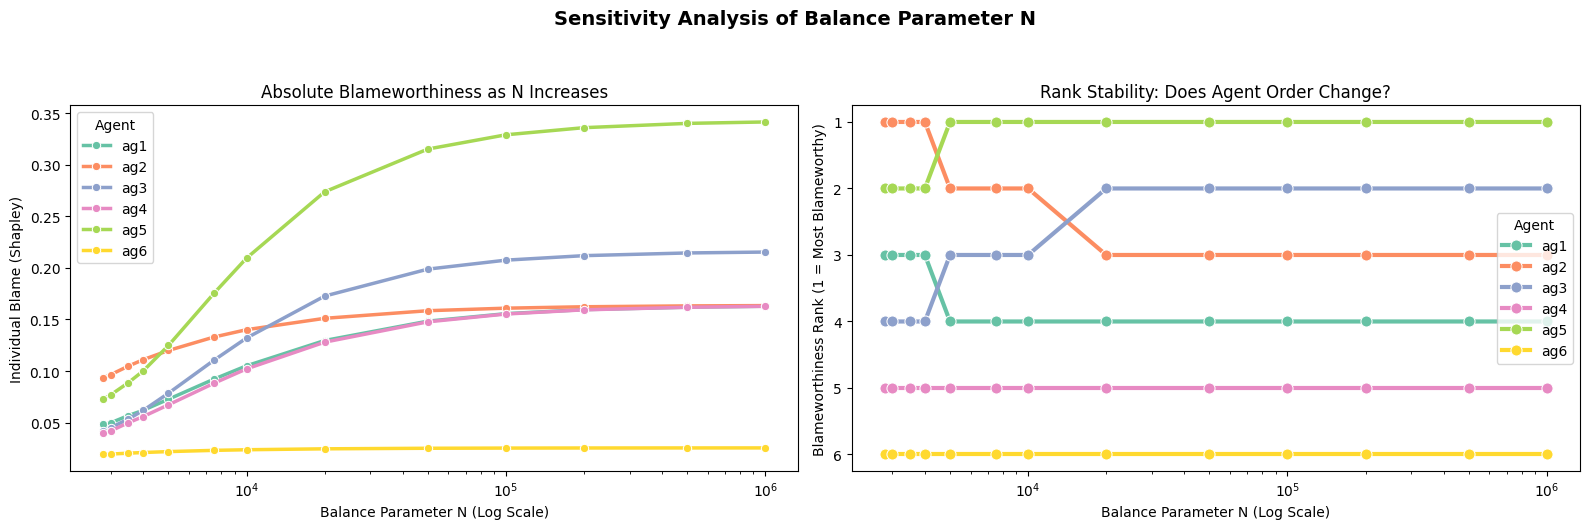

--- Q2: Does Rank Order Change? ---
Top 3 at N=2800: ['ag2', 'ag5', 'ag1']
Top 3 at N=1000000: ['ag5', 'ag3', 'ag2']


In [4]:
# ── Analysis: Rank Order & Sensitivity to Balance Parameter N ───────────────
# Q1: What is the rank of each agent based on theoretical scores?
# Q2: Does the rank order change if we sweep N?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Theoretical Values from the Paper (Section 3.4)
paper_results = {
    'ag5': 0.125, # Base 0.40
    'ag2': 0.120, # Low switch cost (500)
    'ag3': 0.079, # Social pressure less effective
    'ag1': 0.073, # Baseline
    'ag4': 0.068, # Social pressure more expensive
    'ag6': 0.022  # Voted Yes
}

print("--- Q1: Theoretical Rank Order (From Paper's Reported db) ---")
paper_rank = 1
for ag, blame in sorted(paper_results.items(), key=lambda item: item[1], reverse=True):
    print(f"Rank {paper_rank}: {ag} (db ≈ {blame:.3f})")
print("-" * 60)

# 2. Setup for N-Sweep Simulation
AGENTS = ['ag1', 'ag2', 'ag3', 'ag4', 'ag5', 'ag6', 'ag7']

agent_configs = {
    'ag1': {'base': 0.6, 'vote': 0.0, 'effect': 0.05, 'pcost': 100, 'scost': 2000},
    'ag2': {'base': 0.6, 'vote': 0.0, 'effect': 0.05, 'pcost': 100, 'scost': 500},
    'ag3': {'base': 0.6, 'vote': 0.0, 'effect': 0.03, 'pcost': 100, 'scost': 2000},
    'ag4': {'base': 0.6, 'vote': 0.0, 'effect': 0.05, 'pcost': 150, 'scost': 2000},
    'ag5': {'base': 0.4, 'vote': 0.0, 'effect': 0.05, 'pcost': 100, 'scost': 2000},
    'ag6': {'base': 0.6, 'vote': 1.0, 'effect': 0.05, 'pcost': 100, 'scost': 2000},
}

def get_blame_for_sweep(ag_id, cfg, n_val):
    calc = BlameCalculator(
        AGENTS, 
        balance_parameter_N=n_val,
        pressure_effect=cfg['effect'],
        pressure_cost=cfg['pcost'],
        switch_cost=cfg['scost']
    )
    # Build epistemic state
    probs = {other: cfg['base'] for other in AGENTS}
    probs[ag_id] = cfg['vote']
    e1 = EpistemicState(probs)
    
    return calc.apportion_blame_shapley(ag_id, e1)

# Sweep N from just above max cost (2700) up to a very high number
N_values = [2800, 3000, 3500, 4000, 5000, 7500, 10000, 20000, 50000, 100000, 200000, 500000, 1000000]
records = []

for n in N_values:
    for ag, cfg in agent_configs.items():
        blame = get_blame_for_sweep(ag, cfg, n)
        records.append({'N': n, 'Agent': ag, 'Blame': blame})

df_sweep = pd.DataFrame(records)

# Calculate Rank for each N value (1 is highest blame)
df_sweep['Rank'] = df_sweep.groupby('N')['Blame'].rank(ascending=False, method='min')

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = sns.color_palette("Set2", n_colors=6)
agent_order = ['ag1', 'ag2', 'ag3', 'ag4', 'ag5', 'ag6']

# Left Plot: Absolute Blame Value over N
sns.lineplot(data=df_sweep, x='N', y='Blame', hue='Agent', 
             hue_order=agent_order, palette=palette, 
             linewidth=2.5, marker='o', ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Absolute Blameworthiness as N Increases', fontsize=12)
axes[0].set_xlabel('Balance Parameter N (Log Scale)')
axes[0].set_ylabel('Individual Blame (Shapley)')

# Right Plot: Rank Order over N (Bump Chart)
sns.lineplot(data=df_sweep, x='N', y='Rank', hue='Agent', 
             hue_order=agent_order, palette=palette, 
             linewidth=3, marker='o', markersize=8, ax=axes[1])
axes[1].set_xscale('log')
axes[1].invert_yaxis() # Rank 1 at the top
axes[1].set_yticks(range(1, 7))
axes[1].set_title('Rank Stability: Does Agent Order Change?', fontsize=12)
axes[1].set_xlabel('Balance Parameter N (Log Scale)')
axes[1].set_ylabel('Blameworthiness Rank (1 = Most Blameworthy)')

plt.suptitle('Sensitivity Analysis of Balance Parameter N', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Quick summary output
print("--- Q2: Does Rank Order Change? ---")
lowest_n_ranks = df_sweep[df_sweep['N'] == N_values[0]].sort_values('Rank')
highest_n_ranks = df_sweep[df_sweep['N'] == N_values[-1]].sort_values('Rank')
print(f"Top 3 at N={N_values[0]}: {lowest_n_ranks['Agent'].head(3).tolist()}")
print(f"Top 3 at N={N_values[-1]}: {highest_n_ranks['Agent'].head(3).tolist()}")

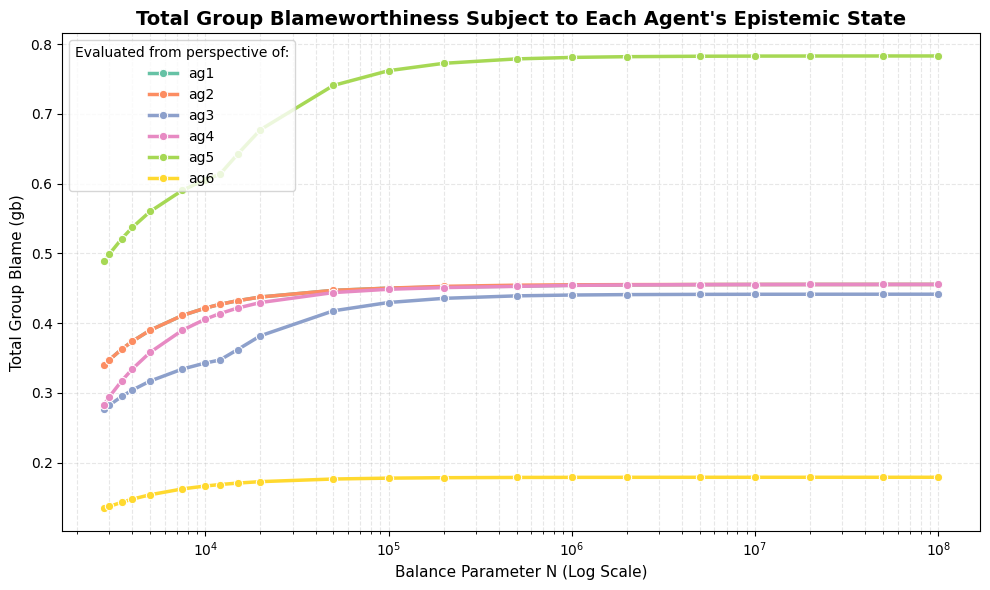

--- Total Group Blame at N=5000 ---
Perspective of ag5: gb = 0.5602
Perspective of ag1: gb = 0.3900
Perspective of ag2: gb = 0.3900
Perspective of ag4: gb = 0.3582
Perspective of ag3: gb = 0.3171
Perspective of ag6: gb = 0.1540


In [5]:
# ── Analysis: Subjective Group Blameworthiness across N ───────────────
# Question: How does the Total Group Blameworthiness change depending 
# on whose epistemic state (beliefs and costs) we are looking through?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

AGENTS = ['ag1', 'ag2', 'ag3', 'ag4', 'ag5', 'ag6', 'ag7']

# Subjective beliefs and costs for each agent (from the paper)
agent_configs = {
    'ag1': {'base': 0.6, 'vote': 0.0, 'effect': 0.05, 'pcost': 100, 'scost': 2000},
    'ag2': {'base': 0.6, 'vote': 0.0, 'effect': 0.05, 'pcost': 100, 'scost': 500},
    'ag3': {'base': 0.6, 'vote': 0.0, 'effect': 0.03, 'pcost': 100, 'scost': 2000},
    'ag4': {'base': 0.6, 'vote': 0.0, 'effect': 0.05, 'pcost': 150, 'scost': 2000},
    'ag5': {'base': 0.4, 'vote': 0.0, 'effect': 0.05, 'pcost': 100, 'scost': 2000},
    'ag6': {'base': 0.6, 'vote': 1.0, 'effect': 0.05, 'pcost': 100, 'scost': 2000},
}

def get_group_blame_for_sweep(ag_id, cfg, n_val):
    calc = BlameCalculator(
        AGENTS, 
        balance_parameter_N=n_val,
        pressure_effect=cfg['effect'],
        pressure_cost=cfg['pcost'],
        switch_cost=cfg['scost']
    )
    # Build this specific agent's epistemic state
    probs = {other: cfg['base'] for other in AGENTS}
    probs[ag_id] = cfg['vote']
    e1 = EpistemicState(probs)
    
    # Calculate TOTAL group blame (all 7 agents) from this agent's perspective
    # We pass target_agent=ag_id because the optimal group action might involve 
    # this specific agent switching their vote at their subjective cost.
    return calc.group_blameworthiness(AGENTS, e1, target_agent=ag_id)

# Sweep N from just above max cost (2800) up to a very high number
N_values = [2800, 3000, 3500, 4000, 5000, 7500, 10000, 12000, 15000, 20000, 50000, 100000, 200000, 500000, 1000000, 2000000, 5000000, 10000000, 20000000, 50000000, 100000000]
records_gb = []

for n in N_values:
    for ag, cfg in agent_configs.items():
        gb = get_group_blame_for_sweep(ag, cfg, n)
        records_gb.append({'N': n, 'Perspective': ag, 'Group Blame': gb})

df_gb = pd.DataFrame(records_gb)

# ── Draw ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
palette = sns.color_palette("Set2", n_colors=6)
agent_order = ['ag1', 'ag2', 'ag3', 'ag4', 'ag5', 'ag6']

sns.lineplot(data=df_gb, x='N', y='Group Blame', hue='Perspective', 
             hue_order=agent_order, palette=palette, 
             linewidth=2.5, marker='o')

plt.xscale('log')
plt.title('Total Group Blameworthiness Subject to Each Agent\'s Epistemic State', fontsize=14, fontweight='bold')
plt.xlabel('Balance Parameter N (Log Scale)', fontsize=11)
plt.ylabel('Total Group Blame (gb)', fontsize=11)
plt.legend(title='Evaluated from perspective of:', loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Print the values at N=5000 (closest to our earlier estimation for the paper)
print("--- Total Group Blame at N=5000 ---")
n_5000_data = df_gb[df_gb['N'] == 5000].sort_values('Group Blame', ascending=False)
for _, row in n_5000_data.iterrows():
    print(f"Perspective of {row['Perspective']}: gb = {row['Group Blame']:.4f}")

# Sweeps for LLM Behavior Evaluation Benchmark (Baseline)

## Summary Sweeps


| Sweep | Parameter |
|-------|-----------|
| 1 | Belief (p₀) |
| 2 | Switch cost × Stakes (c_sw × N) |
| 3 | Own vote |
| 4 | Pressure effect (α) |
| 5 | Threshold |
| 6 | Group size |
<!-- 
| Sweep | Parameter | Theory predicts | Intuition likely predicts     |
|-------|-----------|-----------------|-------------------------------|
| 1 | Belief (p₀) | Non-monotonic peak | Monotonic (either direction) |
| 2 | Switch cost × Stakes (c_sw × N) | Smooth decrease; flatter slope at high stakes | Binary or ignored; stakes-insensitive |
| 3 | Own vote | Nonzero blame for yes-voter | Zero blame for yes-voter |
| 4 | Pressure effect (α) | Non-trivial (marginal contribution) | Monotonic increase or ignored |
| 5 | Threshold | Generally increasing | Decreasing (diffusion) or flat |
| 6 | Group size | Individual ↓, total conserved | Both individual AND total ↓ | -->


## Sweep 1: Belief (p₀)

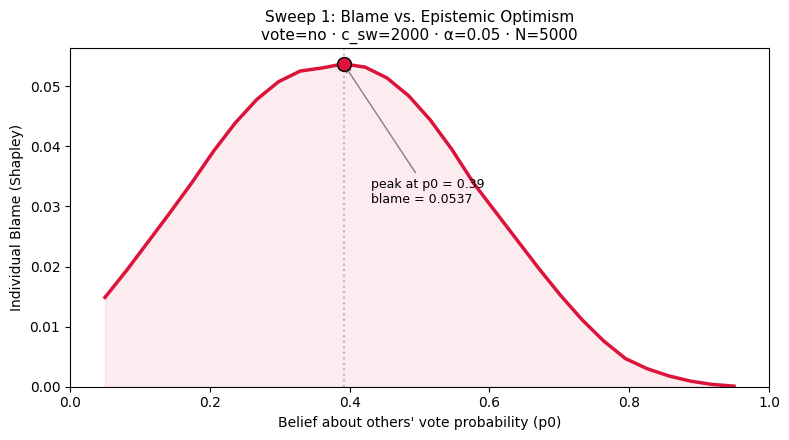

In [47]:
# ── SWEEP 1 BASELINE: Blame vs. Epistemic Optimism (p0) ──────────────────────
# Diagnostic question: is blame non-monotonic (peak at moderate beliefs)?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from committee import BlameCalculator, EpistemicState

AGENTS  = ['ag1','ag2','ag3','ag4','ag5','ag6','ag7']
TARGET  = 'ag1'
N       = 5000
C_SW    = 2000
C_PRESS = 500
ALPHA   = 0.05

base_values = np.linspace(0.05, 0.95, 30)
records = []
for base in base_values:
    calc  = BlameCalculator(AGENTS, N, pressure_effect=ALPHA, pressure_cost=C_PRESS, switch_cost=C_SW)
    probs = {ag: base for ag in AGENTS}
    probs[TARGET] = 0.0
    e1    = EpistemicState(probs)
    blame = calc.apportion_blame_shapley(TARGET, e1)
    records.append({'p0': base, 'blame': blame})

df   = pd.DataFrame(records)
peak = df.loc[df['blame'].idxmax()]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df['p0'], df['blame'], color='crimson', linewidth=2.5)
ax.fill_between(df['p0'], df['blame'], alpha=0.08, color='crimson')
ax.axvline(peak['p0'], color='gray', linestyle=':', alpha=0.5)
ax.scatter([peak['p0']], [peak['blame']], s=100, color='crimson', edgecolors='black', zorder=5)
ax.annotate(f"peak at p0 = {peak['p0']:.2f}\nblame = {peak['blame']:.4f}",
            xy=(peak['p0'], peak['blame']), xytext=(20, -100),
            textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray', lw=1))
ax.set_xlabel("Belief about others' vote probability (p0)", fontsize=10)
ax.set_ylabel('Individual Blame (Shapley)', fontsize=10)
ax.set_title(f'Sweep 1: Blame vs. Epistemic Optimism\nvote=no · c_sw={C_SW} · α={ALPHA} · N={N}', fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

## Sweep 2: Switch cost × Stakes (c_sw × N)

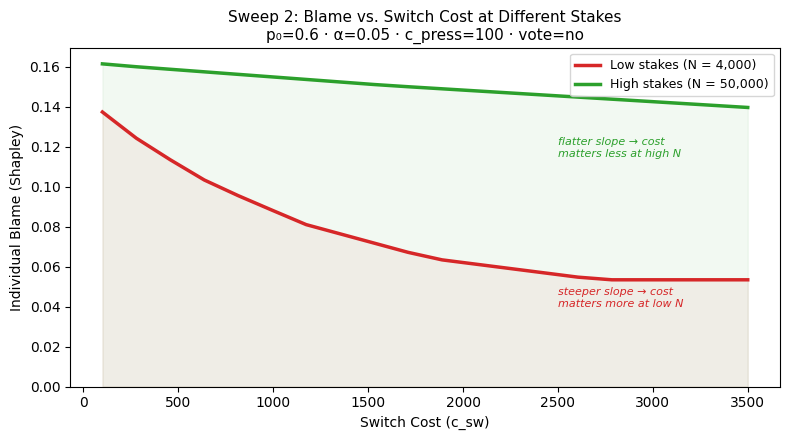

In [21]:
# ── SWEEP 2 BASELINE: Blame vs. Switch Cost at Different Stakes (N) ──────────
# Diagnostic question: does blame decrease with cost, and flatten at high stakes?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from committee import BlameCalculator, EpistemicState

AGENTS  = ['ag1','ag2','ag3','ag4','ag5','ag6','ag7']
TARGET  = 'ag1'
BASE    = 0.6
C_PRESS = 100
ALPHA   = 0.05

csw_values = np.linspace(100, 3500, 20)
stakes     = {'Low stakes (N = 4,000)': 4000, 'High stakes (N = 50,000)': 50000}
colors     = {'Low stakes (N = 4,000)': '#d62728', 'High stakes (N = 50,000)': '#2ca02c'}
records    = []

for label, n_val in stakes.items():
    for csw in csw_values:
        calc  = BlameCalculator(AGENTS, n_val, pressure_effect=ALPHA, pressure_cost=C_PRESS, switch_cost=csw)
        probs = {ag: BASE for ag in AGENTS}
        probs[TARGET] = 0.0
        e1    = EpistemicState(probs)
        blame = calc.apportion_blame_shapley(TARGET, e1)
        records.append({'c_sw': csw, 'Stakes': label, 'blame': blame})

df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(8, 4.5))
for label in stakes:
    sub = df[df['Stakes'] == label]
    ax.plot(sub['c_sw'], sub['blame'], color=colors[label], linewidth=2.5, label=label)
    ax.fill_between(sub['c_sw'], sub['blame'], alpha=0.06, color=colors[label])

ax.annotate('steeper slope → cost\nmatters more at low N', xy=(2500, 0.04), fontsize=8,
            color='#d62728', fontstyle='italic')
ax.annotate('flatter slope → cost\nmatters less at high N', xy=(2500, 0.115), fontsize=8,
            color='#2ca02c', fontstyle='italic')
ax.set_xlabel('Switch Cost (c_sw)', fontsize=10)
ax.set_ylabel('Individual Blame (Shapley)', fontsize=10)
ax.set_title(f'Sweep 2: Blame vs. Switch Cost at Different Stakes\np₀={BASE} · α={ALPHA} · c_press={C_PRESS} · vote=no', fontsize=11)
ax.legend(fontsize=9); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

## Sweep 3: Own vote

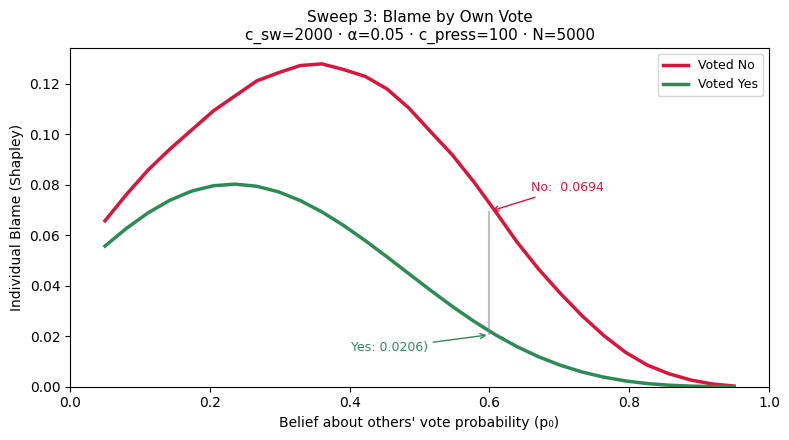

In [33]:
# ── SWEEP 3 BASELINE: Voted No vs. Voted Yes ─────────────────────────────────
# Diagnostic question: does the yes-voter retain nonzero residual blame?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from committee import BlameCalculator, EpistemicState

AGENTS  = ['ag1','ag2','ag3','ag4','ag5','ag6','ag7']
TARGET  = 'ag1'
N       = 5000
C_SW    = 2000
C_PRESS = 100
ALPHA   = 0.05

base_values = np.linspace(0.05, 0.95, 30)
records = []
for base in base_values:
    for vote_label, vote_val in [('Voted No', 0.0), ('Voted Yes', 1.0)]:
        calc  = BlameCalculator(AGENTS, N, pressure_effect=ALPHA, pressure_cost=C_PRESS, switch_cost=C_SW)
        probs = {ag: base for ag in AGENTS}
        probs[TARGET] = vote_val
        e1    = EpistemicState(probs)
        blame = calc.apportion_blame_shapley(TARGET, e1)
        records.append({'p₀': base, 'vote': vote_label, 'blame': blame})

df = pd.DataFrame(records)

# Values at paper default p₀ ≈ 0.6
idx_06   = (df['p₀'] - 0.6).abs().idxmin()  # closest to 0.6 regardless of vote
no_06    = df[(df['vote']=='Voted No')  & (df['p₀'] == df.loc[idx_06, 'p₀'])]['blame'].values[0]
yes_06   = df[(df['vote']=='Voted Yes') & (df['p₀'] == df.loc[idx_06, 'p₀'])]['blame'].values[0]

fig, ax = plt.subplots(figsize=(8, 4.5))
for label, color in [('Voted No', 'crimson'), ('Voted Yes', 'seagreen')]:
    sub = df[df['vote'] == label]
    ax.plot(sub['p₀'], sub['blame'], color=color, linewidth=2.5, label=label)

# Annotate gap at p₀ = 0.6
ax.vlines(0.6, yes_06, no_06, color='gray', linewidth=1.5, linestyle='-', alpha=0.5)
ax.annotate(f'No:  {no_06:.4f}', xy=(0.6, no_06), xytext=(30, 15),
            textcoords='offset points', fontsize=9, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1))
ax.annotate(f'Yes: {yes_06:.4f})',
            xy=(0.6, yes_06), xytext=(-100, -12),
            textcoords='offset points', fontsize=9, color='seagreen',
            arrowprops=dict(arrowstyle='->', color='seagreen', lw=1))
ax.set_xlabel("Belief about others' vote probability (p₀)", fontsize=10)
ax.set_ylabel('Individual Blame (Shapley)', fontsize=10)
ax.set_title(f'Sweep 3: Blame by Own Vote\nc_sw={C_SW} · α={ALPHA} · c_press={C_PRESS} · N={N}', fontsize=11)
ax.legend(fontsize=9); ax.set_xlim(0, 1); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

## Sweep 4: Pressure effect (α) - Coalition reasoning

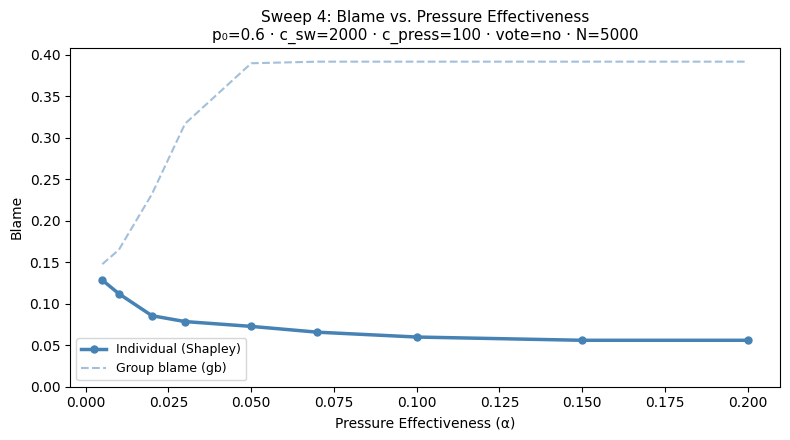

In [32]:
# ── SWEEP 4 BASELINE: Blame vs. Pressure Effectiveness (α) ───────────────────
# Diagnostic question: does blame track available group leverage?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from committee import BlameCalculator, EpistemicState

AGENTS  = ['ag1','ag2','ag3','ag4','ag5','ag6','ag7']
TARGET  = 'ag1'
N       = 5000
BASE    = 0.6
C_SW    = 2000
C_PRESS = 100

alpha_values = [0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20]
records = []
for alpha in alpha_values:
    calc  = BlameCalculator(AGENTS, N, pressure_effect=alpha, pressure_cost=C_PRESS, switch_cost=C_SW)
    probs = {ag: BASE for ag in AGENTS}
    probs[TARGET] = 0.0
    e1    = EpistemicState(probs)
    blame = calc.apportion_blame_shapley(TARGET, e1)
    # Also compute group blame for context
    gb    = calc.group_blameworthiness(AGENTS, e1, target_agent=TARGET)
    records.append({'α': alpha, 'Individual Blame': blame, 'Group Blame': gb})

df = pd.DataFrame(records)

# Mark paper agents
ag1_alpha, ag3_alpha = 0.05, 0.03
ag1_row = df.loc[(df['α'] - ag1_alpha).abs().idxmin()]
ag3_row = df.loc[(df['α'] - ag3_alpha).abs().idxmin()]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df['α'], df['Individual Blame'], color='steelblue', linewidth=2.5, marker='o', markersize=5, label='Individual (Shapley)')
ax.plot(df['α'], df['Group Blame'], color='steelblue', linewidth=1.5, linestyle='--', alpha=0.5, label='Group blame (gb)')

# ax.scatter([ag1_alpha], [ag1_row['Individual Blame']], s=120, marker='*', 
#            color='steelblue', edgecolors='black', zorder=6)
# ax.annotate(f"ag1 (α={ag1_alpha})", xy=(ag1_alpha, ag1_row['Individual Blame']),
#             xytext=(10, 8), textcoords='offset points', fontsize=8, fontweight='bold')
# ax.scatter([ag3_alpha], [ag3_row['Individual Blame']], s=120, marker='*',
#            color='steelblue', edgecolors='black', zorder=6)
# ax.annotate(f"ag3 (α={ag3_alpha})", xy=(ag3_alpha, ag3_row['Individual Blame']),
#             xytext=(10, -12), textcoords='offset points', fontsize=8, fontweight='bold')

ax.set_xlabel('Pressure Effectiveness (α)', fontsize=10)
ax.set_ylabel('Blame', fontsize=10)
ax.set_title(f'Sweep 4: Blame vs. Pressure Effectiveness\np₀={BASE} · c_sw={C_SW} · c_press={C_PRESS} · vote=no · N={N}', fontsize=11)
ax.legend(fontsize=9); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

## Sweep 5: Threshold for bill passing

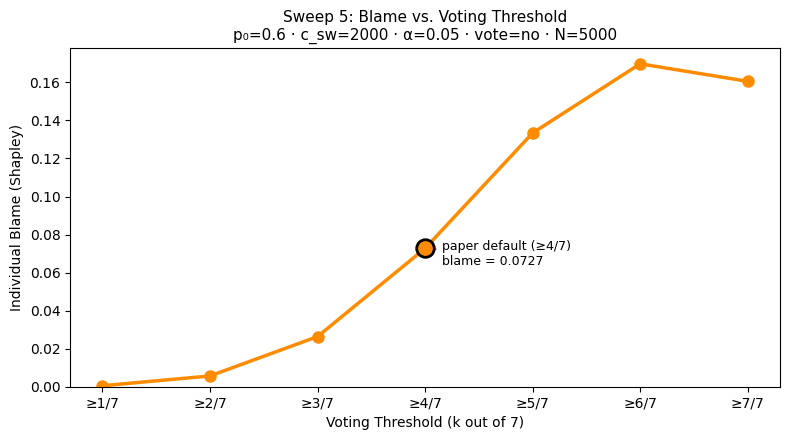

In [35]:
# ── SWEEP 5 BASELINE: Blame vs. Voting Threshold ─────────────────────────────
# Diagnostic question: does blame increase with threshold (pivotality)?

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from committee import BlameCalculator, EpistemicState

AGENTS  = ['ag1','ag2','ag3','ag4','ag5','ag6','ag7']
TARGET  = 'ag1'
N       = 5000
BASE    = 0.6
C_SW    = 2000
C_PRESS = 100
ALPHA   = 0.05

class ThresholdEpistemicState(EpistemicState):
    """EpistemicState with configurable voting threshold."""
    def __init__(self, probabilities_dict, threshold=4):
        super().__init__(probabilities_dict)
        self.threshold = threshold
    def get_outcome_probability(self):
        agents = list(self.probs.keys())
        pass_prob = 0.0
        for i in range(len(agents) + 1):
            for yes_voters in itertools.combinations(agents, i):
                if len(yes_voters) >= self.threshold:
                    wp = 1.0
                    for ag in agents:
                        wp *= self.probs[ag] if ag in yes_voters else (1 - self.probs[ag])
                    pass_prob += wp
        return pass_prob

def blame_at_threshold(threshold):
    calc  = BlameCalculator(AGENTS, N, pressure_effect=ALPHA, pressure_cost=C_PRESS, switch_cost=C_SW)
    probs = {ag: BASE for ag in AGENTS}
    probs[TARGET] = 0.0
    e1 = ThresholdEpistemicState(probs, threshold=threshold)
    # Patch simulate_action to preserve threshold
    _orig = calc.simulate_action
    def _patched(cids, bs, switcher_id=None, target_id=None, _o=_orig, _t=threshold):
        e2, cost = _o(cids, bs, switcher_id=switcher_id, target_id=target_id)
        return ThresholdEpistemicState(e2.probs, threshold=_t), cost
    calc.simulate_action = _patched
    return calc.apportion_blame_shapley(TARGET, e1)

thresholds = list(range(1, 8))
records = [{'threshold': t, 'blame': blame_at_threshold(t)} for t in thresholds]
df = pd.DataFrame(records)

paper_val = df[df['threshold'] == 4]['blame'].values[0]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df['threshold'], df['blame'], color='darkorange', linewidth=2.5, marker='o', markersize=8)
ax.scatter([4], [paper_val], s=160, color='darkorange', edgecolors='black', linewidths=2, zorder=6)
ax.annotate(f'paper default (≥4/7)\nblame = {paper_val:.4f}', xy=(4, paper_val),
            xytext=(12, -12), textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray', lw=1))
ax.set_xlabel('Voting Threshold (k out of 7)', fontsize=10)
ax.set_ylabel('Individual Blame (Shapley)', fontsize=10)
ax.set_xticks(thresholds)
ax.set_xticklabels([f'≥{k}/7' for k in thresholds])
ax.set_title(f'Sweep 5: Blame vs. Voting Threshold\np₀={BASE} · c_sw={C_SW} · α={ALPHA} · vote=no · N={N}', fontsize=11)
ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

## Sweep 6: Group size

n=3  threshold=≥2  individual=0.2446  gb=0.3119  total=0.7339
n=5  threshold=≥3  individual=0.1210  gb=0.3738  total=0.6050
n=7  threshold=≥4  individual=0.0727  gb=0.3900  total=0.5092
n=9  threshold=≥5  individual=0.0441  gb=0.3328  total=0.3967


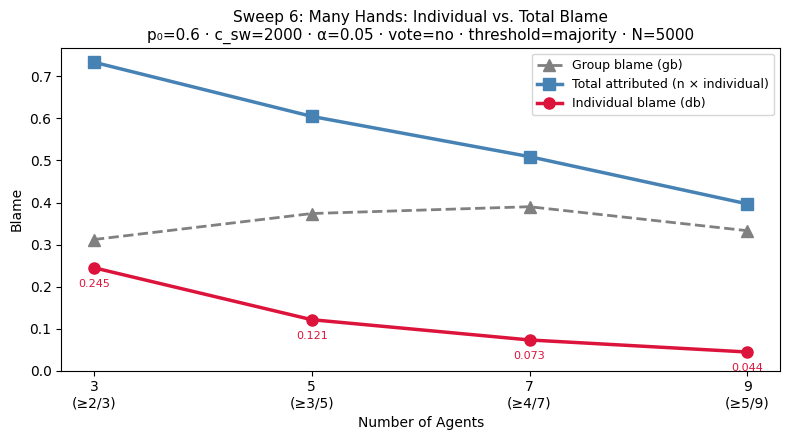

In [37]:
# ── SWEEP 6 BASELINE: Many Hands — Individual vs. Total Blame ────────────────
# Diagnostic question: does total blame conserve as group grows (Efficiency)?
# NOTE: n=9 may take a few minutes (2^8 = 256 Shapley coalitions)

import itertools, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from committee import BlameCalculator, EpistemicState

N       = 5000
BASE    = 0.6
C_SW    = 2000
C_PRESS = 100
ALPHA   = 0.05

class ThresholdEpistemicState(EpistemicState):
    """EpistemicState with configurable voting threshold."""
    def __init__(self, probabilities_dict, threshold=4):
        super().__init__(probabilities_dict)
        self.threshold = threshold
    def get_outcome_probability(self):
        agents = list(self.probs.keys())
        pass_prob = 0.0
        for i in range(len(agents) + 1):
            for yes_voters in itertools.combinations(agents, i):
                if len(yes_voters) >= self.threshold:
                    wp = 1.0
                    for ag in agents:
                        wp *= self.probs[ag] if ag in yes_voters else (1 - self.probs[ag])
                    pass_prob += wp
        return pass_prob

group_sizes = [3, 5, 7, 9]
records = []

for n_agents in group_sizes:
    agents    = [f'ag{i+1}' for i in range(n_agents)]
    target    = agents[0]
    threshold = math.ceil(n_agents / 2)  # simple majority

    calc  = BlameCalculator(agents, N, pressure_effect=ALPHA, pressure_cost=C_PRESS, switch_cost=C_SW)
    probs = {ag: BASE for ag in agents}
    probs[target] = 0.0

    e1 = ThresholdEpistemicState(probs, threshold=threshold)

    # Patch simulate_action to preserve threshold
    _orig = calc.simulate_action
    def _patched(cids, bs, switcher_id=None, target_id=None, _o=_orig, _t=threshold):
        e2, cost = _o(cids, bs, switcher_id=switcher_id, target_id=target_id)
        return ThresholdEpistemicState(e2.probs, threshold=_t), cost
    calc.simulate_action = _patched

    ind_blame = calc.apportion_blame_shapley(target, e1)
    gb        = calc.group_blameworthiness(agents, e1, target_agent=target)
    total     = n_agents * ind_blame  # Efficiency: should ≈ gb

    records.append({
        'n': n_agents, 'threshold': f'≥{threshold}/{n_agents}',
        'Individual': ind_blame, 'Group (gb)': gb, 'Total (n × db)': total,
    })
    print(f"n={n_agents}  threshold=≥{threshold}  individual={ind_blame:.4f}  gb={gb:.4f}  total={total:.4f}")

df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df['n'], df['Group (gb)'],      color='gray',      linewidth=2, linestyle='--', marker='^',
        markersize=8, label='Group blame (gb)', zorder=3)
ax.plot(df['n'], df['Total (n × db)'],  color='steelblue', linewidth=2.5, marker='s',
        markersize=8, label='Total attributed (n × individual)', zorder=4)
ax.plot(df['n'], df['Individual'],       color='crimson',   linewidth=2.5, marker='o',
        markersize=8, label='Individual blame (db)', zorder=5)

# Annotate the key diagnostic: total vs gb
for _, row in df.iterrows():
    ax.annotate(f"{row['Individual']:.3f}", xy=(row['n'], row['Individual']),
                xytext=(0, -14), textcoords='offset points', fontsize=8,
                ha='center', color='crimson')

ax.set_xlabel('Number of Agents', fontsize=10)
ax.set_ylabel('Blame', fontsize=10)
ax.set_xticks(group_sizes)
ax.set_xticklabels([f'{n}\n(≥{math.ceil(n/2)}/{n})' for n in group_sizes])
ax.set_title(f'Sweep 6: Many Hands: Individual vs. Total Blame\np₀={BASE} · c_sw={C_SW} · α={ALPHA} · vote=no · threshold=majority · N={N}', fontsize=11)
ax.legend(fontsize=9); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

## Report Figure: RQ1 Parameter Sensitivity (2×3 composite)

Clean composite figure for the report. Saves to `../report/img/04_rq1_sensitivity.png`.

saved → ./plots/04_rq1_sensitivity.png


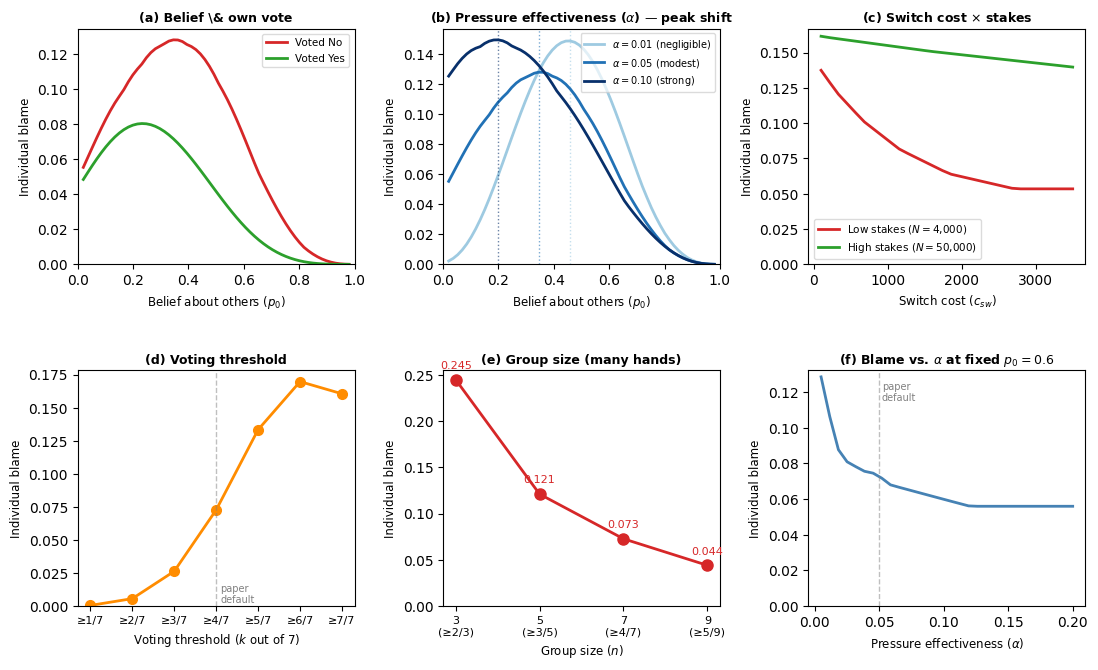

In [1]:
# ── REPORT FIGURE: RQ1 Parameter Sensitivity (2×3 composite) ────────────────
# Clean version for the report — no diagnostic annotations, no dual axes.
# Saves to ../report/img/04_rq1_sensitivity.png

import itertools, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from committee import BlameCalculator, EpistemicState

AGENTS  = ['ag1','ag2','ag3','ag4','ag5','ag6','ag7']
TARGET  = 'ag1'
N       = 5000
C_SW    = 2000
C_PRESS = 100
ALPHA   = 0.05
BASE    = 0.6

class ThresholdEpistemicState(EpistemicState):
    def __init__(self, probs, threshold=4):
        super().__init__(probs)
        self.threshold = threshold
    def get_outcome_probability(self):
        agents = list(self.probs.keys())
        pass_prob = 0.0
        for i in range(len(agents) + 1):
            for yes_voters in itertools.combinations(agents, i):
                if len(yes_voters) >= self.threshold:
                    wp = 1.0
                    for ag in agents:
                        wp *= self.probs[ag] if ag in yes_voters else (1 - self.probs[ag])
                    pass_prob += wp
        return pass_prob

def blame_threshold(agents, target, n_bal, alpha, c_press, c_sw, probs, threshold):
    calc = BlameCalculator(agents, n_bal, pressure_effect=alpha, pressure_cost=c_press, switch_cost=c_sw)
    e1 = ThresholdEpistemicState(probs, threshold=threshold)
    _orig = calc.simulate_action
    def _p(cids, bs, switcher_id=None, target_id=None, _o=_orig, _t=threshold):
        e2, cost = _o(cids, bs, switcher_id=switcher_id, target_id=target_id)
        return ThresholdEpistemicState(e2.probs, _t), cost
    calc.simulate_action = _p
    return calc.apportion_blame_shapley(target, e1)

p0_vals = np.linspace(0.02, 0.98, 60)

# (a) Blame vs p0 — no-voter and yes-voter
rec_a = []
for p0 in p0_vals:
    for vote_label, vote_val in [('Voted No', 0.0), ('Voted Yes', 1.0)]:
        calc = BlameCalculator(AGENTS, N, pressure_effect=ALPHA, pressure_cost=C_PRESS, switch_cost=C_SW)
        probs = {ag: p0 for ag in AGENTS}; probs[TARGET] = vote_val
        rec_a.append({'p0': p0, 'vote': vote_label,
                      'blame': calc.apportion_blame_shapley(TARGET, EpistemicState(probs))})
df_a = pd.DataFrame(rec_a)

# (b) Blame vs p0 for three alpha values — peak shift
alpha_cfg = {0.01: r'$\alpha=0.01$ (negligible)', 0.05: r'$\alpha=0.05$ (modest)',
             0.10: r'$\alpha=0.10$ (strong)'}
rec_b = []
for alpha, label in alpha_cfg.items():
    for p0 in p0_vals:
        calc = BlameCalculator(AGENTS, N, pressure_effect=alpha, pressure_cost=C_PRESS, switch_cost=C_SW)
        probs = {ag: p0 for ag in AGENTS}; probs[TARGET] = 0.0
        rec_b.append({'p0': p0, 'label': label, 'alpha': alpha,
                      'blame': calc.apportion_blame_shapley(TARGET, EpistemicState(probs))})
df_b = pd.DataFrame(rec_b)

# (c) Blame vs switch cost at two stakes levels
csw_vals = np.linspace(100, 3500, 30)
stakes_cfg = [('Low stakes ($N=4{,}000$)', 4000, '#d62728'),
              ('High stakes ($N=50{,}000$)', 50000, '#2ca02c')]
rec_c = []
for label, n_val, _ in stakes_cfg:
    for csw in csw_vals:
        calc = BlameCalculator(AGENTS, n_val, pressure_effect=ALPHA, pressure_cost=C_PRESS, switch_cost=csw)
        probs = {ag: BASE for ag in AGENTS}; probs[TARGET] = 0.0
        rec_c.append({'csw': csw, 'stakes': label,
                      'blame': calc.apportion_blame_shapley(TARGET, EpistemicState(probs))})
df_c = pd.DataFrame(rec_c)

# (d) Blame vs voting threshold
thresholds = list(range(1, 8))
rec_d = [{'threshold': t,
           'blame': blame_threshold(AGENTS, TARGET, N, ALPHA, C_PRESS, C_SW,
                                    {**{ag: BASE for ag in AGENTS}, TARGET: 0.0}, t)}
         for t in thresholds]
df_d = pd.DataFrame(rec_d)

# (e) Individual blame vs group size
group_sizes = [3, 5, 7, 9]
rec_e = []
for n_agents in group_sizes:
    agents = [f'ag{i+1}' for i in range(n_agents)]
    t = math.ceil(n_agents / 2)
    blame = blame_threshold(agents, agents[0], N, ALPHA, C_PRESS, C_SW,
                            {**{ag: BASE for ag in agents}, agents[0]: 0.0}, t)
    rec_e.append({'n': n_agents, 'blame': blame, 'label': f'{n_agents}\n(≥{t}/{n_agents})'})
df_e = pd.DataFrame(rec_e)

# (f) Blame vs alpha at fixed p0 = 0.6 (counterintuitive decrease)
alpha_vals_f = np.linspace(0.005, 0.20, 30)
rec_f = []
for alpha in alpha_vals_f:
    calc = BlameCalculator(AGENTS, N, pressure_effect=alpha, pressure_cost=C_PRESS, switch_cost=C_SW)
    probs = {ag: BASE for ag in AGENTS}; probs[TARGET] = 0.0
    rec_f.append({'alpha': alpha,
                  'blame': calc.apportion_blame_shapley(TARGET, EpistemicState(probs))})
df_f = pd.DataFrame(rec_f)

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
fig.subplots_adjust(hspace=0.45, wspace=0.32)

LKW = dict(fontsize=8.5)
TKW = dict(fontsize=9, fontweight='bold', pad=5)

# (a)
ax = axes[0, 0]
for vote, color in [('Voted No', '#d62728'), ('Voted Yes', '#2ca02c')]:
    sub = df_a[df_a['vote'] == vote]
    ax.plot(sub['p0'], sub['blame'], color=color, linewidth=2, label=vote)
ax.set_xlabel('Belief about others ($p_0$)', **LKW)
ax.set_ylabel('Individual blame', **LKW)
ax.set_title('(a) Belief \& own vote', **TKW)
ax.set_xlim(0, 1); ax.set_ylim(bottom=0)
ax.legend(fontsize=7.5, framealpha=0.7)

# (b)
ax = axes[0, 1]
colors_b = ['#9ecae1', '#2171b5', '#08306b']
for (alpha, label), color in zip(sorted(alpha_cfg.items()), colors_b):
    sub = df_b[df_b['alpha'] == alpha]
    peak_p0 = sub.loc[sub['blame'].idxmax(), 'p0']
    ax.plot(sub['p0'], sub['blame'], color=color, linewidth=2, label=label)
    ax.axvline(peak_p0, color=color, linestyle=':', linewidth=1, alpha=0.6)
ax.set_xlabel('Belief about others ($p_0$)', **LKW)
ax.set_ylabel('Individual blame', **LKW)
ax.set_title('(b) Pressure effectiveness ($\\alpha$) — peak shift', **TKW)
ax.set_xlim(0, 1); ax.set_ylim(bottom=0)
ax.legend(fontsize=7, framealpha=0.7)

# (c)
ax = axes[0, 2]
for label, n_val, color in stakes_cfg:
    sub = df_c[df_c['stakes'] == label]
    ax.plot(sub['csw'], sub['blame'], color=color, linewidth=2, label=label)
ax.set_xlabel('Switch cost ($c_{sw}$)', **LKW)
ax.set_ylabel('Individual blame', **LKW)
ax.set_title('(c) Switch cost $\\times$ stakes', **TKW)
ax.set_ylim(bottom=0)
ax.legend(fontsize=7.5, framealpha=0.7)

# (d)
ax = axes[1, 0]
ax.plot(df_d['threshold'], df_d['blame'], color='darkorange', linewidth=2, marker='o', markersize=7)
ax.axvline(4, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.text(4.1, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.001, 'paper\ndefault',
        fontsize=7, color='gray', va='bottom')
ax.set_xlabel('Voting threshold ($k$ out of 7)', **LKW)
ax.set_ylabel('Individual blame', **LKW)
ax.set_title('(d) Voting threshold', **TKW)
ax.set_xticks(thresholds)
ax.set_xticklabels([f'≥{k}/7' for k in thresholds], fontsize=8)
ax.set_ylim(bottom=0)

# (e)
ax = axes[1, 1]
ax.plot(df_e['n'], df_e['blame'], color='#d62728', linewidth=2, marker='o', markersize=8)
for _, row in df_e.iterrows():
    ax.annotate(f"{row['blame']:.3f}", xy=(row['n'], row['blame']),
                xytext=(0, 8), textcoords='offset points', fontsize=8,
                ha='center', color='#d62728')
ax.set_xlabel('Group size ($n$)', **LKW)
ax.set_ylabel('Individual blame', **LKW)
ax.set_title('(e) Group size (many hands)', **TKW)
ax.set_xticks(df_e['n'])
ax.set_xticklabels(df_e['label'], fontsize=8)
ax.set_ylim(bottom=0)

# (f)
ax = axes[1, 2]
ax.plot(df_f['alpha'], df_f['blame'], color='steelblue', linewidth=2)
ax.axvline(0.05, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.text(0.052, df_f['blame'].max() * 0.98, 'paper\ndefault', fontsize=7, color='gray', va='top')
ax.set_xlabel('Pressure effectiveness ($\\alpha$)', **LKW)
ax.set_ylabel('Individual blame', **LKW)
ax.set_title('(f) Blame vs. $\\alpha$ at fixed $p_0=0.6$', **TKW)
ax.set_ylim(bottom=0)

OUT = './plots/04_rq1_sensitivity.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight')
print(f'saved → {OUT}')
plt.show()
